Shape: (7043, 21)

First 5 rows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperless

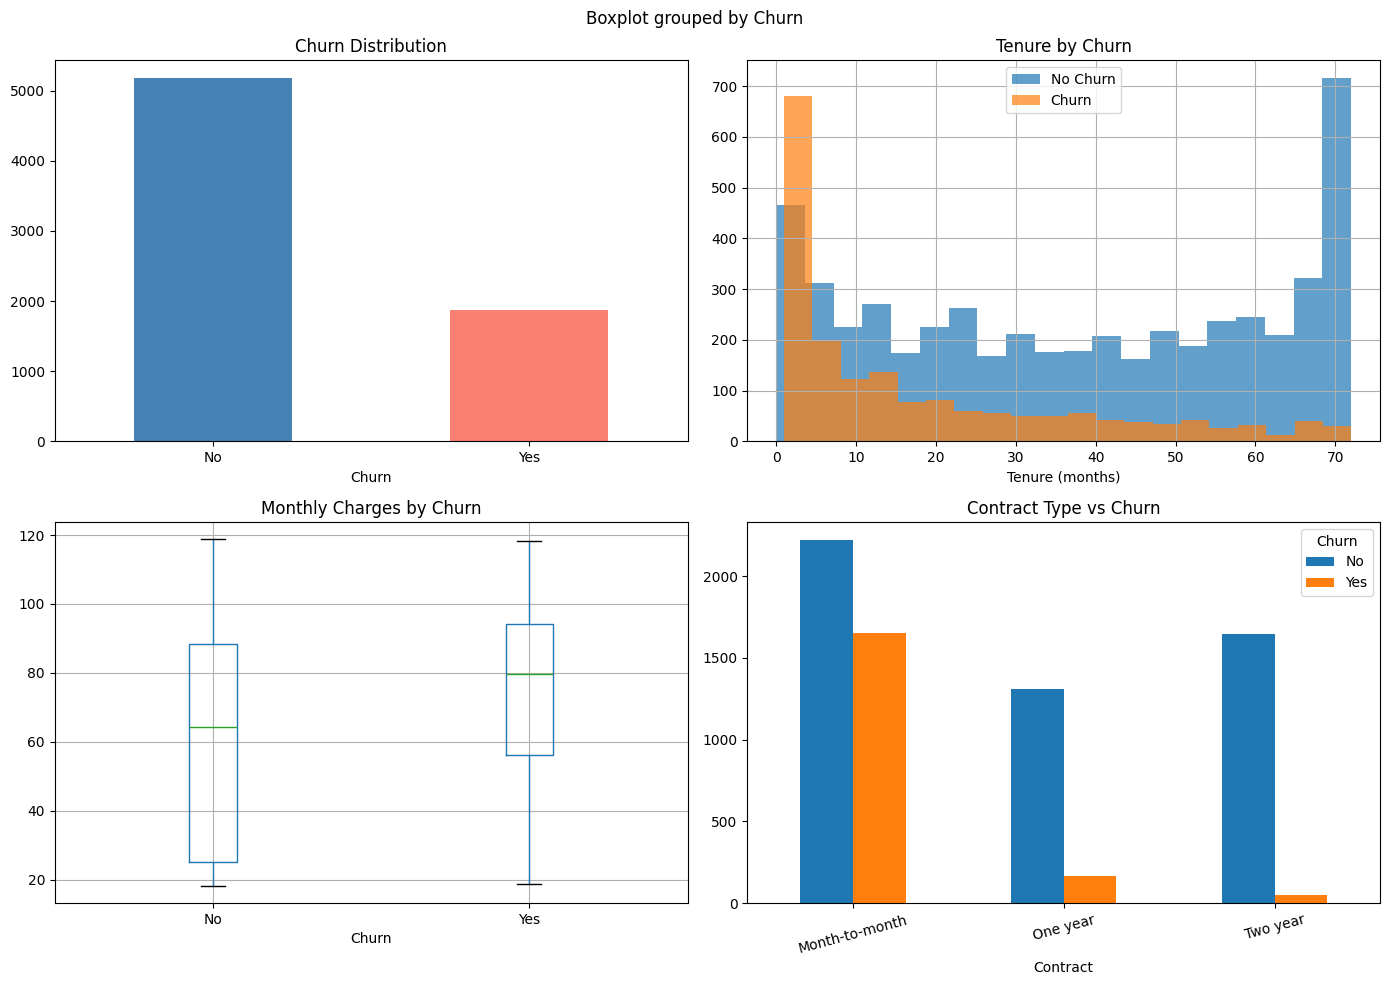

object
['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95']

Missing values:
TotalCharges    11
dtype: int64

Missing values after fix:
0
Final shape: (7043, 33)
Features created: 32
Class balance:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Train: (5634, 32), Test: (1409, 32)
Before SMOTE: {0: 4139, 1: 1495}
After SMOTE:  {0: 4139, 1: 4139}
Model                           F1      AUC  Precision     Recall
-----------------------------------------------------------------
Logistic Regression          0.613    0.846      0.505      0.781
Decision Tree                0.610    0.812      0.530      0.719
Random Forest                0.573    0.825      0.562      0.586
XGBoost                      0.613    0.839      0.575      0.655

Best model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78   

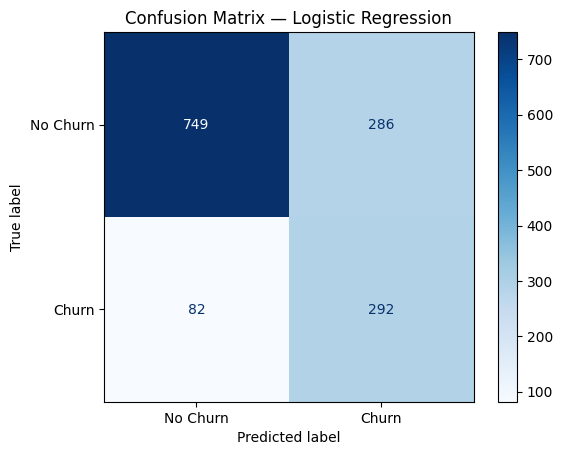

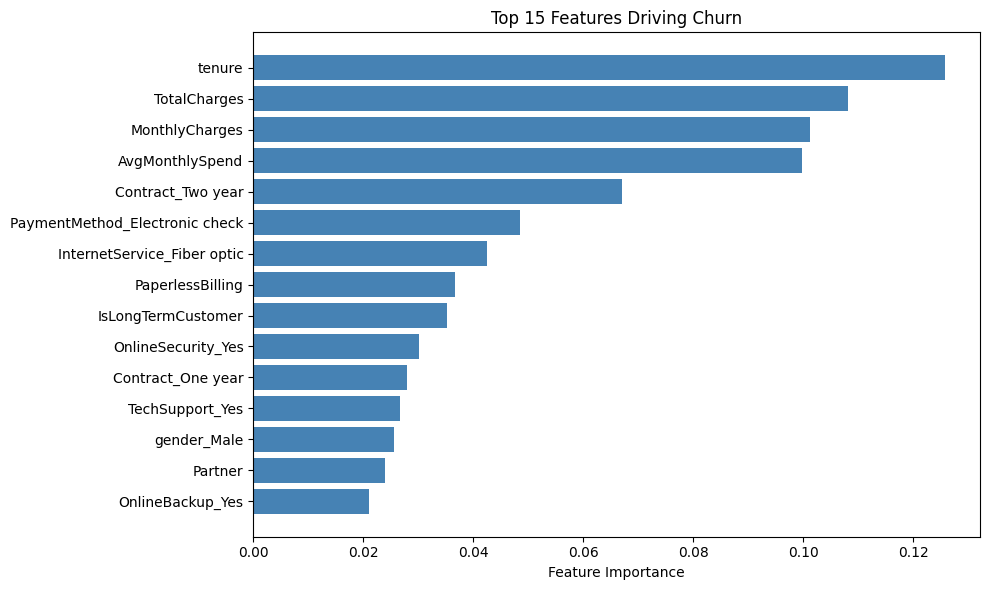

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

print(df.info())
print("\n")

print("Churn distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3) * 100, "%")

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title("Churn Distribution")
plt.xticks(rotation=0)

plt.subplot(2, 2, 2)
df.groupby('Churn')['tenure'].hist(alpha=0.7, bins=20)
plt.title("Tenure by Churn")
plt.xlabel("Tenure (months)")
plt.legend(['No Churn', 'Churn'])

plt.subplot(2, 2, 3)
df.boxplot(column='MonthlyCharges', by='Churn', ax=plt.gca())
plt.title("Monthly Charges by Churn")

plt.subplot(2, 2, 4)
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar', ax=plt.gca())
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


print(df['TotalCharges'].dtype)
print(df['TotalCharges'].unique()[:10])

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

df.drop('customerID', axis=1, inplace=True)

print("\nMissing values after fix:")
print(df.isnull().sum().sum())

df['Churn'] = (df['Churn'] == 'Yes').astype(int)

df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
df['IsLongTermCustomer'] = (df['tenure'] > 24).astype(int)

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype(int)

cat_cols = ['gender', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Final shape:", df.shape)
print("Features created:", df.shape[1] - 1)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1)
y = df['Churn']

print("Class balance:")
print(y.value_counts(normalize=True).round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")


from imblearn.over_sampling import SMOTE


smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_sm).value_counts().to_dict())


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.metrics import (classification_report, roc_auc_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             xgb.XGBClassifier(n_estimators=100, learning_rate=0.1,
                                              max_depth=4, random_state=42,
                                              eval_metric='logloss', verbosity=0)
}

results = {}

print(f"{'Model':<25} {'F1':>8} {'AUC':>8} {'Precision':>10} {'Recall':>10}")
print("-" * 65)

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]

    f1  = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    from sklearn.metrics import precision_score, recall_score
    pre = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)

    results[name] = {'F1': f1, 'AUC': auc, 'Precision': pre, 'Recall': rec}
    print(f"{name:<25} {f1:>8.3f} {auc:>8.3f} {pre:>10.3f} {rec:>10.3f}")

best_name = max(results, key=lambda x: results[x]['F1'])
best_model = models[best_name]

preds_best = best_model.predict(X_test_scaled)

print(f"\nBest model: {best_name}")
print("\nClassification Report:")
print(classification_report(y_test, preds_best, target_names=['No Churn', 'Churn']))

cm = confusion_matrix(y_test, preds_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix — {best_name}")
plt.show()

rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X.columns

top_indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 6))
plt.barh(range(15), importances[top_indices][::-1], color='steelblue')
plt.yticks(range(15), [feature_names[i] for i in top_indices][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Features Driving Churn")
plt.tight_layout()
plt.show()
